# 04 - Comparação de Modelos: TF-IDF vs Embeddings (MiniLM English)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Caminhos dos resultados
baseline_path = Path("../models/results_baseline.csv")
embeddings_path = Path("../models/results_embeddings.csv")

baseline = pd.read_csv(baseline_path)
embeddings = pd.read_csv(embeddings_path)

baseline["Tipo"] = "TF-IDF"
embeddings["Tipo"] = "Embeddings"

df_all = pd.concat([baseline, embeddings])
df_all

,Modelo,Acurácia,F1-Score,AUC,Tipo
0,Regressão Logística,0.9565,0.9568,0.9565,TF-IDF
1,SVM Linear,0.9602,0.9601,0.9602,TF-IDF
2,Naive Bayes,0.8750,0.8701,0.8750,TF-IDF
3,Random Forest,0.9611,0.9614,0.9611,TF-IDF
0,Logistic Regression (Embeddings),0.7926,0.7821,0.8805,Embeddings
1,Linear SVM (Embeddings),0.8130,0.8069,0.8946,Embeddings


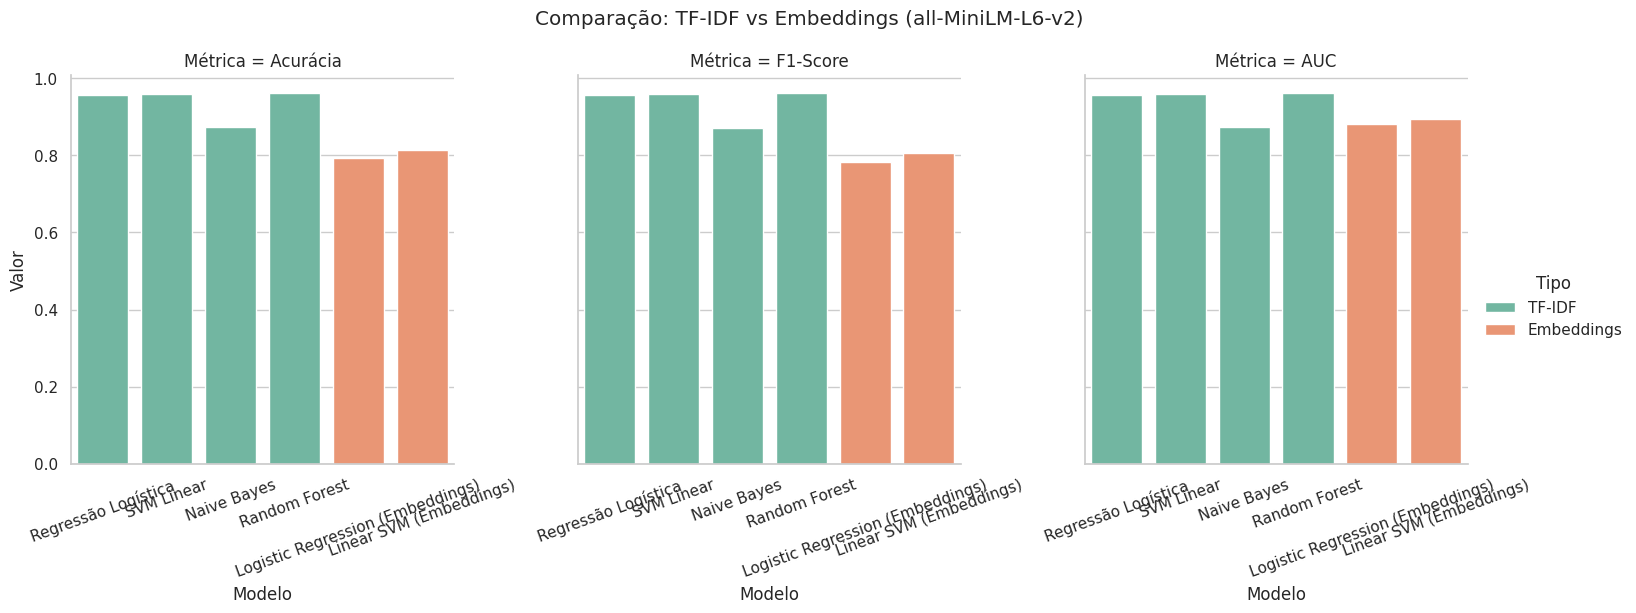

In [2]:
sns.set(style="whitegrid")
df_melted = df_all.melt(id_vars=["Modelo", "Tipo"], 
                        value_vars=["Acurácia", "F1-Score", "AUC"],
                        var_name="Métrica", value_name="Valor")

# Gráficos lado a lado por métrica
g = sns.catplot(
    data=df_melted, 
    x="Modelo", y="Valor", hue="Tipo", 
    col="Métrica", kind="bar", 
    height=5, aspect=1, palette="Set2"
)
g.fig.suptitle("Comparação: TF-IDF vs Embeddings (all-MiniLM-L6-v2)", y=1.05)
g.set_xticklabels(rotation=20)
plt.show()


### Conclusões

- O modelo **TF-IDF + Random Forest** apresentou o melhor desempenho geral (F1 ≈ 0.96), 
  enquanto os modelos com embeddings **all-MiniLM-L6-v2** atingiram cerca de F1 ≈ 0.81.
- Essa diferença é esperada: o *Fake.br Corpus* é pequeno (~7 mil textos) e fortemente lexical,
  o que favorece métodos baseados em frequência de termos.
- Os **Sentence Transformers** capturam contexto semântico, mas requerem fine-tuning ou
  grandes volumes de dados para superarem abordagens clássicas.
- Assim, o TF-IDF permanece o **baseline mais eficaz** e interpretável neste domínio,
  enquanto os embeddings demonstram o potencial das representações semânticas
  em aplicações futuras com bases maiores.